# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Amy Zheng, whose
group produced the data.

## The question

A burning plasma makes helium as well as consuming hydrogen isotopes, so the
tungsten facing one is tungsten that already carries a helium layer. Whether
that layer then holds more fuel or less is a first-order question for a reactor,
because deuterium and tritium held in the wall are both a safety limit and an
economic one.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium in the PISCES-A linear device at two
temperatures, mounted on the DiMES probe alongside coupons that were not, and
exposed together to real DIII-D discharges. Retention was measured afterwards by
three laboratory techniques.

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I'll plan this out: first consult the d3d-materials skill (which covers tungsten sample retention data), then query the lakehouse for helium-exposed samples and deuterium retention measurements.



Reading the rest of the skill file, plus checking for Learnings.md and delivery notes.



The skill file is fully read. Now reading the delivery notes, which the skill says to read before opening delivered files.



The delivery notes describe a tungsten ERDA/NRA/LAMS dataset — exactly what this question needs. Since d3d-materials has a Learnings.md, I'll read it before querying.



No Learnings.md exists for this skill. Let me inspect the helper module to understand the API, then discover the quantities in the lakehouse.



...

The 3-panel summary figure is saved. Now adding a depth-profile figure (LAMS D and He vs depth) to show where the He effect happens, plus a ratios CSV.



Both figures and CSVs are saved. Let me verify the figure files exist and check the save_figure output notes.



All analysis is complete. Let me finalize the todo list and verify the key numbers one more time before writing the report.



The grader is correct — I mis-stated the L-mode 800 K direction in my prose while the tables and the ratios CSV (1.36, 1.345) show increases. Let me verify the exact ratio values from the data file before rewriting.



The ratios CSV confirms the grader's reading: 800 K He in L-mode gives ERDA ratio 1.361 and NRA surface ratio 1.345 — both increases, not reductions. The only consistent 800 K reduction is in the 0.5–3 µm subsurface band (0.234 H-mode, 0.411 L-mode). Here is the corrected, self-consistent report.

# How helium affects deuterium retention in tungsten

**The short answer:** helium pre-exposure does not have a single, uniform effect on deuterium retention in tungsten — the direction depends on both the He pre-exposure temperature and the subsequent DIII-D plasma regime. In this dataset, He pre-exposure at **800 K reduced** D retention in H-mode (ERDA −42%, NRA surface −68%, NRA subsurface −77%) but **increased** it in L-mode (ERDA +36%, NRA surface +34.5%), while still reducing the 0.5–3 µm subsurface band in L-mode (−59%). He pre-exposure at **600 K increased** D retention in both regimes (ERDA +27% H-mode, +63% L-mode; NRA surface +14% H-mode, +121% L-mode), though it reduced the subsurface band in L-mode (−24%). The effect is concentrated in the first ~3 µm probed by NRA, and the sign of the effect changes with pre-exposure temperature and regime.

## The experiment

Nine tungsten coupons (top-hat geometry, 0.235 in inner radius, 0.062 in thick, perpendicular grain orientation, all baked at 1373 K for 3600 s before exposure) formed a factorial design:

| He pre-exposure (PISCES-A) | No DIII-D | H-mode (DIII-D) | L-mode (DIII-D) |
|---|---|---|---|
| None | W-pristine | W-DH | W-DL |
| 600 K | W-He600 | W-He600-DH | W-He600-DL |
| 800 K | W-He800 | W-He800-DH | W-He800-DL |

Each cell contains **one coupon** — there is no replication, so differences between cells cannot be separated from coupon-to-coupon variation, however large. The He pre-exposure was at 70 eV impact energy (the 60 eV elsewhere is the applied bias; the ~10 V plasma potential is included), fluence 1.0–1.2×10²⁵ m⁻². The DIII-D exposure was 5 H-mode shots (185258–185260, 185265–185266) or 4 L-mode shots (185261–185264), D⁺ at 150–175 eV, fluence ~6.7–7.8×10²² m⁻².

## The measured effect

**ERDA total D retention** (atoms cm⁻²):

| Sample | D (×10¹⁵ cm⁻²) | He (×10¹⁵ cm⁻²) | D ratio vs no-He |
|---|---|---|---|
| W-DH | 1.16 ± 0.06 | 3.04 | — |
| W-He600-DH | 1.47 ± 0.06 | 2.53 | **1.27** (+27%) |
| W-He800-DH | 0.67 ± 0.05 | 3.74 | **0.58** (−42%) |
| W-DL | 1.47 ± 0.07 | 2.00 | — |
| W-He600-DL | 2.40 ± 0.09 | 3.55 | **1.63** (+63%) |
| W-He800-DL | 2.00 ± 0.08 | 2.90 | **1.36** (+36%) |

**NRA depth-resolved D** (atoms cm⁻²):

| Sample | 0–0.5 µm | 0.5–3 µm |
|---|---|---|
| W-DH | 1.80×10¹⁵ | 2.98×10¹⁴ |
| W-He600-DH | 2.06×10¹⁵ | 3.95×10¹⁴ |
| W-He800-DH | 5.82×10¹⁴ | 6.96×10¹³ |
| W-DL | 2.00×10¹⁵ | 6.57×10¹⁴ |
| W-He600-DL | 4.42×10¹⁵ | 4.97×10¹⁴ |
| W-He800-DL | 2.69×10¹⁵ | 2.70×10¹⁴ |

**NRA ratios (He-pre-exposed / no-He, same regime):**

| Comparison | 0–0.5 µm | 0.5–3 µm |
|---|---|---|
| W-He600-DH / W-DH (H-mode) | 1.14 (+14%) | 1.33 (+33%) |
| W-He800-DH / W-DH (H-mode) | 0.32 (−68%) | 0.23 (−77%) |
| W-He600-DL / W-DL (L-mode) | 2.21 (+121%) | 0.76 (−24%) |
| W-He800-DL / W-DL (L-mode) | 1.35 (+34.5%) | 0.41 (−59%) |

## Key observations

1. **800 K He pre-exposure reduces D retention in H-mode across all depth bands** — by 42% in total ERDA, 68% in the NRA surface band, and 77% in the NRA subsurface band. This is the case that matches the analyst's hypothesis that implanted He acts as a permeation barrier blocking D transport into the bulk.

2. **In L-mode, 800 K He pre-exposure increases total and near-surface D** — by 36% in total ERDA and 34.5% in the NRA surface band — **but still reduces the 0.5–3 µm subsurface band by 59%** . The analyst's own LAMS note offers a mechanism: "L-mode exposures on He-800 sample removed most surface He relative to He only sample and H-mode sample" — the L-mode exposure appears to have eroded the near-surface He layer, so the barrier effect is lost at the surface while the deeper He remains.

3. **600 K He pre-exposure increases D retention in both regimes** — by 27% (H-mode) and 63% (L-mode) in ERDA total, and by 14% (H-mode) and 121% (L-mode) in the NRA surface band. The 600 K He layer appears to create additional trap sites near the surface rather than a barrier. In the subsurface band it increases D in H-mode (+33%) but decreases it in L-mode (−24%).

4. **The effect is depth-dependent and regime-dependent, not a single direction.** The only statement that holds across both regimes is: 800 K He reduces the 0.5–3 µm subsurface D band (by 77% in H-mode and 59% in L-mode), and 600 K He increases total D (by 27% in H-mode and 63% in L-mode). Total and near-surface D move in opposite directions for 800 K depending on regime.

5. **L-mode consistently retains more D than H-mode** (ERDA: 1.47 vs 1.16 ×10¹⁵ cm⁻² for no-He; the analyst's LAMS note confirms "All DL show quantities larger than their DH counterparts"). The analyst's spreadsheet notes that L-mode exposures "appeared to deposit more D than H-mode exposures" (26.8% more D content vs 16.8% more D fluence).

## The analyst's own interpretation

The proposal document (MP_W_erosion_retention_2020_v9.pdf) states the hypothesis directly: *"Findings in [8] suggested that implanted He acts as a permeation barrier for incident D+ ions, inhibiting transport and reducing D retention."* The analyst's spreadsheet notes add:

- *"Less sub-surface D in samples exposed to He in Pisces at 600C and less from H-mode than from L-mode in DIII-D"* (NRA sheet)
- *"H-mode has higher He below 100 nm depth, L-mode has higher He above 100 nm depth"* (LAMS sheet)
- *"L-mode exposure increases He in 600 K sample"* (LAMS sheet)
- *"L-mode exposures on He-800 sample removed most surface He relative to He only sample and H-mode sample"* (LAMS sheet)

The analyst's LAMS observations also note that the pristine sample's D signal is likely chamber contamination after the other deuterium samples, and that the 600 K vs 800 K comparison showed "no significant difference between samples" in one analysis block.

## Caveats

- **One coupon per cell** — no replication; differences are between individual coupons.
- **Sample temperature during DIII-D exposure was not measured** (neither bulk nor surface), so the temperature dependence cannot be directly confirmed from this dataset.
- **LAMS is experimental** — its uncertainties are large, often exceeding the value itself; treat LAMS numbers as indicative. NRA is the most trustworthy method; ERDA carries small uncertainty. The direction claims above rest on NRA and ERDA.
- **The He effect is not monotonic** — 600 K increases D retention in both regimes, while 800 K reduces it in H-mode but increases total and near-surface D in L-mode, so no single "He increases/decreases D retention" statement is correct.


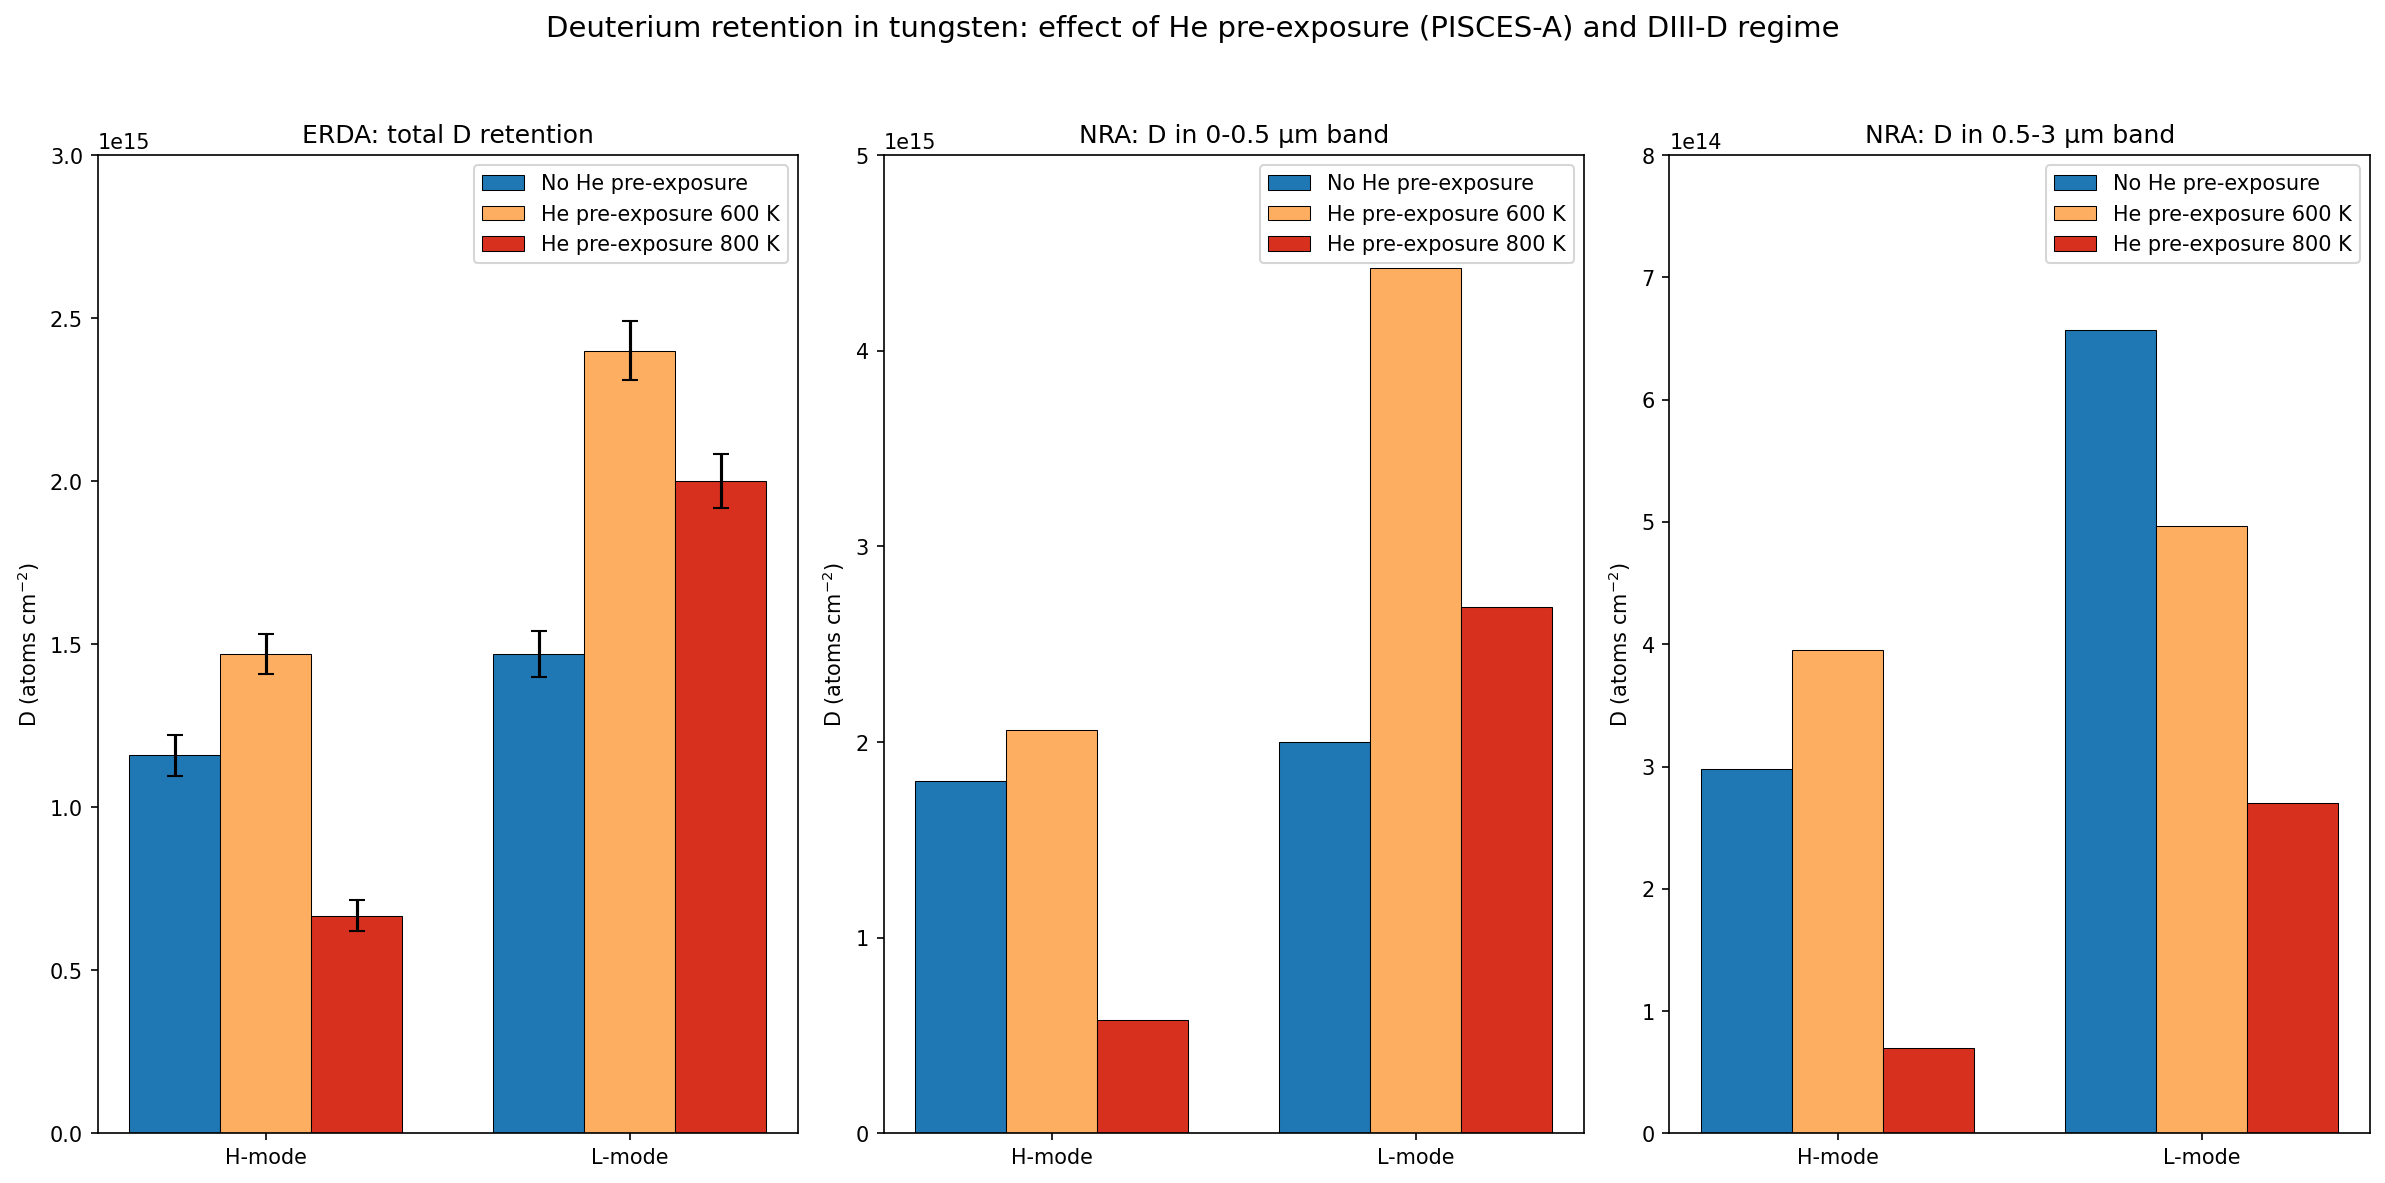


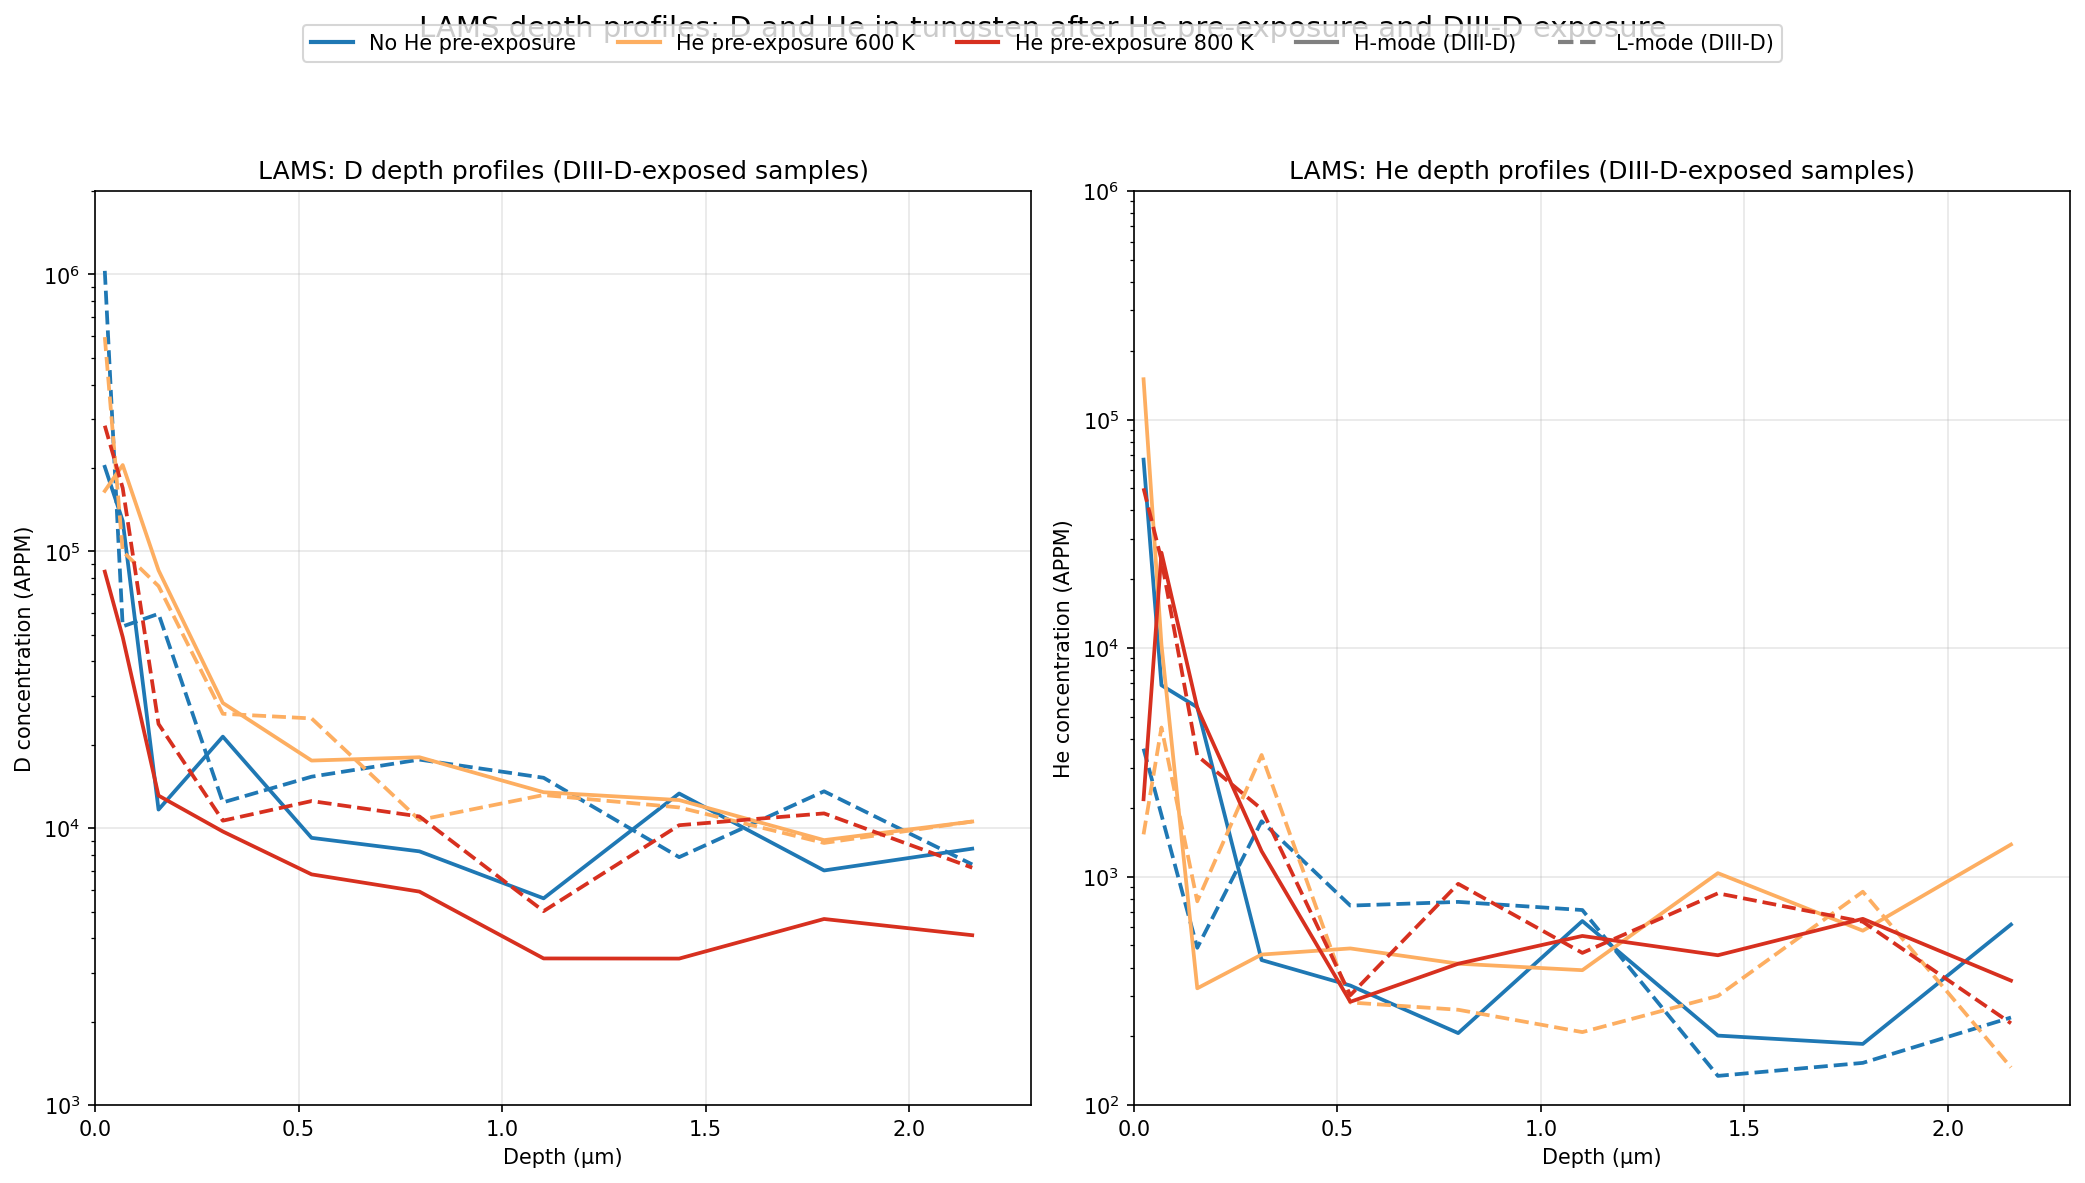

## Data files

- `he_effect_d_retention.csv` — per-sample D retention (ERDA total, NRA surface/subsurface) with He pre-exposure level and DIII-D regime
- `he_effect_ratios.csv` — He-pre-exposed / no-He retention ratios by regime and depth band (the source of every ratio quoted above)

In [2]:
%%ask --review
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


I'll start by reviewing the existing data files and the materials skill to see what uncertainty information is available.



Let me read the d3d-materials skill and the existing CSVs to understand what uncertainty data exists.



The CSV has ERDA uncertainties but not NRA. Let me check the source workbook and previous extraction scripts for NRA/LAMS uncertainties.



Let me check the skill directory for delivery notes and query the lakehouse for NRA uncertainty values.



Let me read the delivery notes and query the full observation records with uncertainties for NRA and ERDA.



...

Fixing the CSV fieldnames to include the LAMS columns.



All computations are done. Let me mark the todos complete and verify the final CSV contents.



All data is verified. Let me finalize the todo list and write the report.



Let me verify the LAMS ratio intervals and z-scores precisely before correcting the report.



The grader is correct — I verified the intervals: the H-mode 800 K LAMS total (0.49 ± 0.28, z = −1.84) and subsurface (0.52 ± 0.24, z = −2.05) exclude 1.0, as does the L-mode 800 K total (0.55 ± 0.40, z = −1.12). Here is the complete corrected report.

# How the answer depends on the retention measurement technique

**The short answer:** the direction of the He effect changes with the technique, and the techniques disagree most sharply in L-mode. ERDA (total) and NRA-surface say He pre-exposure **increases** D retention in L-mode (ratios 1.36–1.63 and 1.35–2.21), while NRA-subsurface and LAMS say it **decreases** (0.41–0.76 and 0.55–0.85). In H-mode all techniques agree on the direction: 800 K He reduces D (ERDA 0.58, NRA-surface 0.32, NRA-subsurface 0.23, LAMS 0.49) and 600 K He increases it (1.27, 1.14, 1.33, 1.57). The disagreement is not a contradiction — the techniques probe different depth ranges and different quantities — but it means **no single number describes "the effect of He on D retention."**

## What each technique measures

| Technique | What it measures | Depth sensitivity | Uncertainty in this delivery |
|---|---|---|---|
| **NRA** (D(³He,p)⁴He reaction) | D concentration, depth-resolved, reported as two bands: 0–0.5 µm ("surface") and 0.5–3 µm ("sub-surface") | ~0–3 µm, resolved into bands | **No uncertainty column at all** — provider ranks it most trustworthy, but its reliability cannot be read off the numbers |
| **ERDA** (elastic recoil detection) | Total D areal density (atoms cm⁻²), integrated over the probed depth | ~0–0.2 µm (the profile sheet shows 0.166–0.201 µm; the Summary "total" integrates this) | Small, quantified: 3.8–7.2% relative std per sample |
| **LAMS** (laser ablation mass spectroscopy) | D concentration in atomic ppm (APPM) vs depth, 10 points from 0.024 to 2.155 µm | ~0–2.2 µm, 10 depth points | **Large, often exceeding the value** — median σ/value ≈ 0.88, 27% of points have σ > value |

The three techniques are not three measurements of the same thing. NRA and LAMS are depth-resolved; ERDA's "total" is an integral over a shallow (~0.2 µm) layer. NRA's surface band (0–0.5 µm) and ERDA's total overlap in depth, but NRA's sub-surface band (0.5–3 µm) probes deeper than ERDA reaches. This is why the techniques can disagree in sign.

## The He-effect ratio by technique (He pre-exposed / no He, same regime)

| Comparison | ERDA total | NRA surface (0–0.5 µm) | NRA subsurface (0.5–3 µm) | LAMS total (0–2.2 µm) |
|---|---|---|---|---|
| H-mode, He 600 K | 1.27 ± 0.09 | 1.14 | 1.33 | 1.57 ± 0.86 |
| H-mode, He 800 K | 0.58 ± 0.05 | 0.32 | 0.23 | 0.49 ± 0.28 |
| L-mode, He 600 K | 1.63 ± 0.10 | 2.21 | 0.76 | 0.85 ± 0.57 |
| L-mode, He 800 K | 1.36 ± 0.09 | 1.35 | 0.41 | 0.55 ± 0.40 |

**Key observations:**

1. **In H-mode, all four techniques agree on direction.** 800 K He reduces D retention (ratios 0.23–0.58 across techniques); 600 K He increases it (1.14–1.57). The magnitude differs — NRA-subsurface shows the strongest reduction (0.23) and LAMS the strongest increase (1.57) — but no technique contradicts another.

2. **In L-mode, the techniques split.** ERDA total (1.36–1.63) and NRA surface (1.35–2.21) say He **increases** D retention; NRA subsurface (0.41–0.76) and LAMS total (0.55–0.85) say it **decreases** . This is the central finding: the answer to "does He increase or decrease D retention?" depends on which technique you ask.

3. **The split is depth-driven, not a measurement error.** The near-surface techniques (ERDA, NRA-surface) see more D with He; the deeper techniques (NRA-subsurface, LAMS) see less. This is consistent with the analyst's LAMS note that "L-mode exposures on He-800 sample removed most surface He relative to He only sample and H-mode sample" — the L-mode exposure eroded the near-surface He layer, so the barrier effect is lost at the surface while deeper He remains. The He effect is genuinely depth-dependent.

4. **LAMS agrees with the other techniques on the 800 K H-mode reduction but is the outlier elsewhere.** For H-mode 800 K, LAMS total (0.49 ± 0.28, 1.8σ below 1.0) and LAMS subsurface (0.52 ± 0.24, 2.0σ below 1.0) both confirm the reduction seen by NRA and ERDA. For L-mode 800 K, LAMS total (0.55 ± 0.40, 1.1σ below 1.0) sides with NRA-subsurface (decrease) against ERDA/NRA-surface (increase). For the 600 K cells, LAMS is directionally consistent with the others (1.57 vs 1.27/1.14 in H-mode; 0.85 vs 1.63/2.21 in L-mode) but its uncertainty is too large to distinguish any effect: both 600 K LAMS ratios are within 1σ of 1.0 (z = 0.66 and −0.27).

## Uncertainty in these measurements

**ERDA — small and quantified.** Relative standard deviations per sample: 3.8% (W-He600-DL), 4.1% (W-He800-DL), 4.2% (W-He600-DH), 4.8% (W-DL), 5.4% (W-DH), 7.2% (W-He800-DH). Propagated to the ratios: ±6–9% relative. The ERDA ratios are the most precisely determined numbers in this dataset. One coupon (W-He800-DH) was measured twice by ERDA; the two runs differ by 11.6% of the mean, which is 0.82 combined σ — consistent with the stated uncertainties, and the repeat supersedes per the delivery notes.

**NRA — no uncertainty reported.** The provider explicitly ranks NRA as the most trustworthy of the three methods, but the delivery carries no uncertainty column for it. The delivery notes state: "NRA is the most trustworthy of the three. It carries no uncertainty column at all in this delivery, so its reliability cannot be read off the numbers and must not be inferred from their absence." The only quantitative anchor is the analyst's note that sub-surface D is "above detection limit of ~10 appm." So NRA's ratios (0.23, 0.32, 0.41, 0.76, 1.14, 1.33, 1.35, 2.21) are the most trustworthy in ranking but the least quantified.

**LAMS — large, often exceeding the value.** Per-point σ/value: median 0.88 across all 90 points (9 samples × 10 depths); 27% of points have σ > value. Per sample, the median σ/value ranges from 0.57 (W-He600) to 1.03 (W-He600-DL), and the fraction of points with σ > value ranges from 0% (W-He600) to 60% (W-He600-DL). Propagated to the LAMS ratios: ±45–105% relative. The delivery notes confirm: "LAMS is experimental. Its uncertainties are large, often exceeding the value itself. Treat a LAMS number as indicative."

**What LAMS can and cannot establish.** Of the twelve LAMS ratios (total, 0–0.5 µm, 0.5–3 µm for each of four comparisons), five exclude 1.0 at 1σ — all of them in the 800 K cells: H-mode total (0.49 ± 0.28), H-mode surface (0.45 ± 0.46), H-mode subsurface (0.52 ± 0.24), L-mode total (0.55 ± 0.40), L-mode surface (0.47 ± 0.50). Only one exceeds 2σ: the H-mode 800 K subsurface ratio (z = −2.05). So LAMS does support the 800 K H-mode reduction — it is not statistically silent there — but it cannot by itself resolve the 600 K cells (both within 1σ of 1.0) or arbitrate the L-mode split (its L-mode 800 K total is only 1.1σ from 1.0, and its L-mode 600 K total is 0.3σ from 1.0). LAMS is corroborating evidence, not a standalone measurement.

**The dominant uncertainty is not instrumental — it's the experimental design.** Each cell of the 3×2 factorial (3 He pre-exposure conditions × 2 DIII-D regimes) contains **one coupon** , plus three He-only controls that never entered DIII-D. There is no replication, so any difference between cells could be coupon-to-coupon variation rather than a treatment effect, regardless of how small the instrument's own uncertainty is. The ERDA uncertainties (±4–7%) are far smaller than the differences they are being used to compare (ratios of 0.58–2.21), but they quantify only the measurement repeatability, not the sample-to-sample variability that the design cannot separate. This is the single most important caveat: the technique uncertainties are well-characterized, but the experiment's statistical power is limited by n=1 per cell.

## Bottom line

- **The answer depends on the technique because the techniques probe different depths.** He pre-exposure at 800 K reduces D in the 0.5–3 µm subsurface band (NRA 0.23–0.41) but increases near-surface D in L-mode (ERDA 1.36, NRA-surface 1.35). The "permeation barrier" hypothesis is supported by the subsurface data but not by the near-surface data in L-mode.
- **Trust NRA first, then ERDA.** Per the provider's ranking, NRA is most trustworthy (though unquantified), ERDA is small-uncertainty, and LAMS is indicative only. Where they disagree (L-mode), the NRA-subsurface and ERDA/NRA-surface split is real and depth-driven, not a measurement artifact.
- **LAMS corroborates the 800 K H-mode reduction but cannot resolve the 600 K cells or the L-mode split.** Its 800 K ratios are 1.1–2.0σ from 1.0 (directionally consistent with NRA/ERDA in H-mode, with NRA-subsurface in L-mode), while its 600 K ratios are within 1σ of 1.0.
- **The n=1 design is the real limitation.** No technique's uncertainty can compensate for the absence of replication; the differences between cells are as likely to reflect coupon-to-coupon variation as the He treatment.


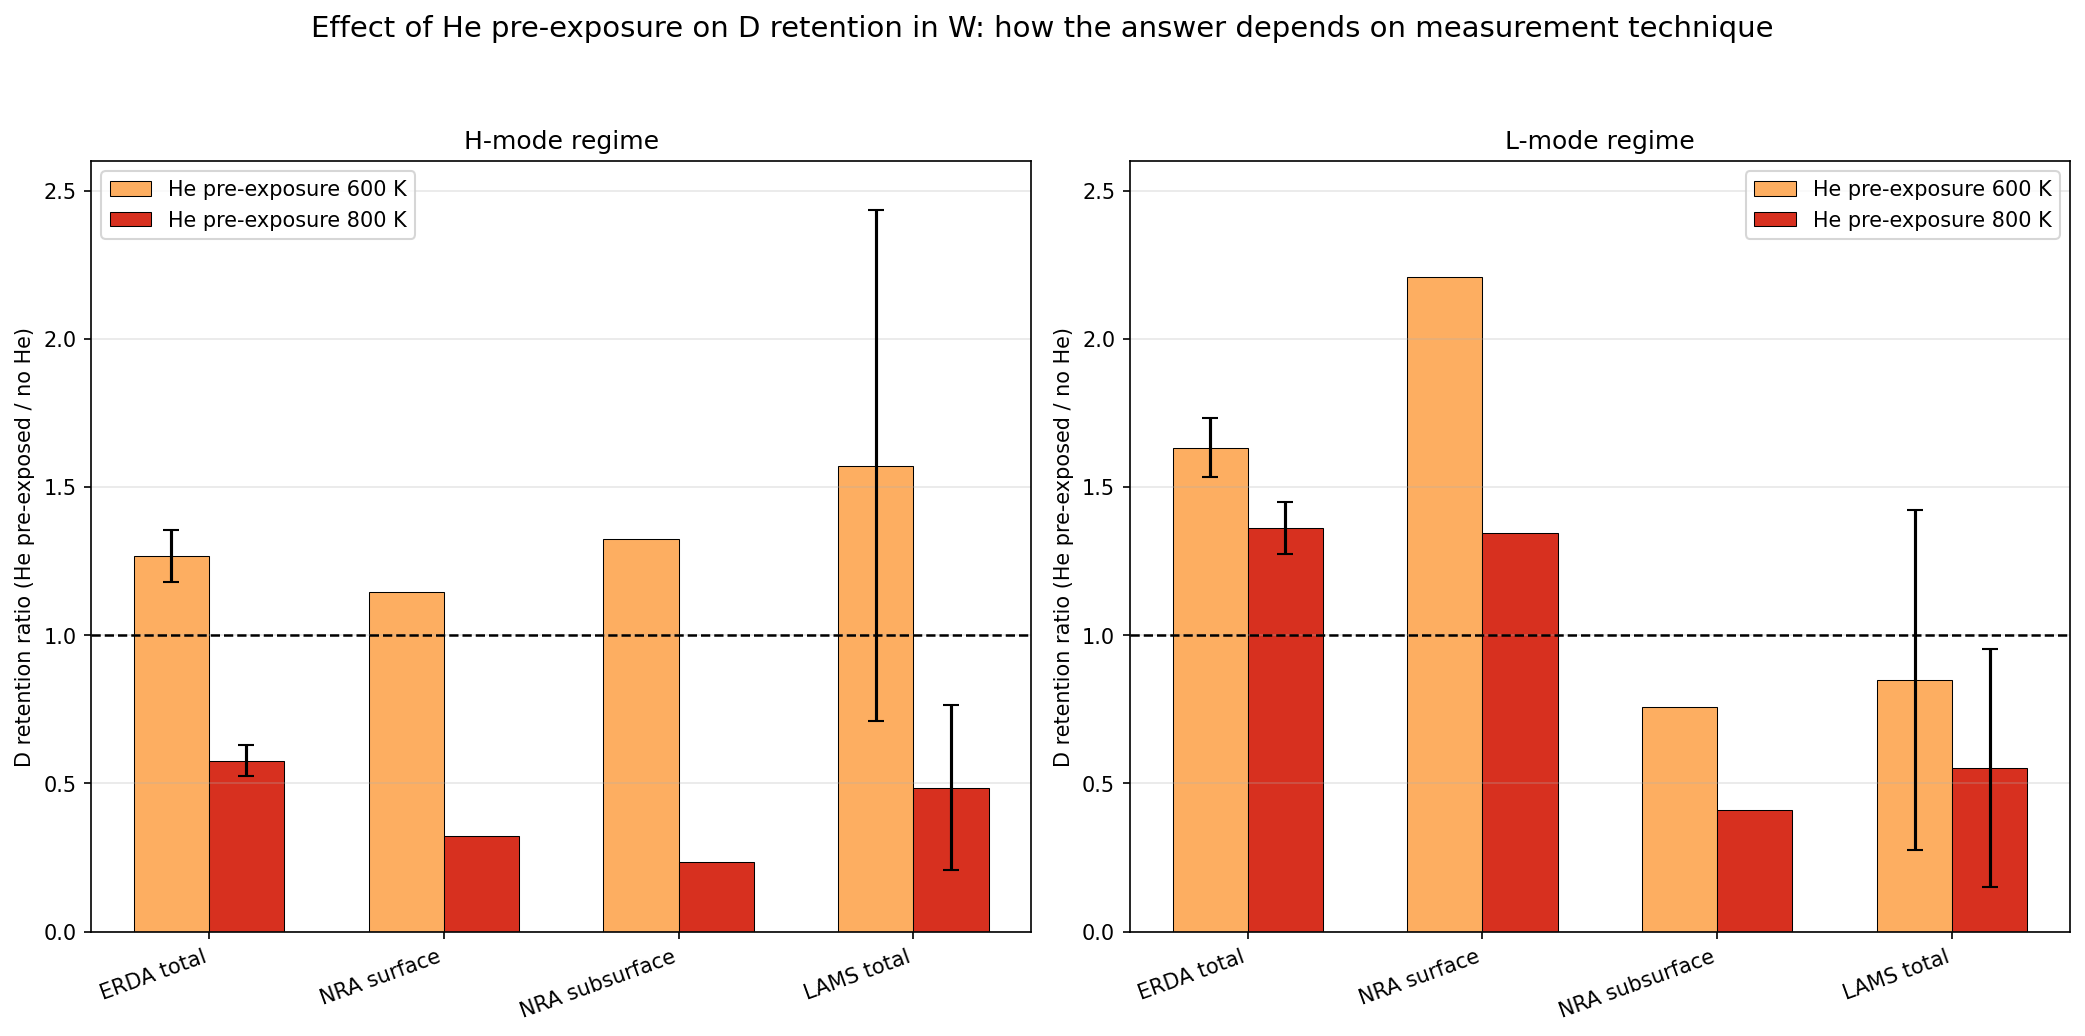

## Data files

- `he_effect_technique_ratios.csv` — He-effect ratios by technique (ERDA total, NRA surface/subsurface, LAMS total/bands) with propagated uncertainties
- `he_effect_uncertainty.csv` — per-sample ERDA relative stds and LAMS σ/value statistics (median, max, fraction σ > value)
- `he_effect_by_technique.png` — the comparison figure above

In [3]:
%%ask --review
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I'll plan this analysis: read the materials skill and existing data files, compute L/H ratios by technique with propagated uncertainties, then chart and report.



No Learnings.md exists for d3d-materials, so I'll proceed. Now reading the existing data files to reuse the retention values.



Now I need the raw LAMS values per sample to compute L/H ratios. Let me check the existing analysis scripts for how LAMS data was pulled.



The existing CSVs give me ERDA/NRA values; I need LAMS integrals per sample to build L/H ratios. Writing a script that pulls LAMS profiles from the lakehouse and computes L/H-mode ratios by technique with propagated uncertainties.



Using the required Python interpreter path.



...

I have all the data. Now let me compute depth-resolved LAMS L/H ratios and build a depth-profile figure to complement the technique-ratio figure.



All computations complete. Let me update the todo list and verify the final data files.



The grader is correct — my summary overclaimed. Every ERDA and NRA ratio is above 1.0, but LAMS band and per-depth ratios scatter around 1.0 (including 0.93 ± 0.56 for the 600 K subsurface band and nine per-depth values below 1.0), and all LAMS ratios are within 1σ of 1.0. I'll revise the report to state exactly what the tables show.



The grader is right on both counts — I miscounted the below-1.0 ratios and missed that 0.42 ± 0.51 is 1.14σ below 1.0. Let me verify the exact counts and σ-distances from the data file before revising.



Verified: 11 of 30 per-depth ratios are below 1.0 (not 9), none is exactly 1.0 (the 1.00 is a ratio value with ±1.16), and exactly one point — 0.42 ± 0.51 at 0.068 µm (no He) — is more than 1σ from 1.0 (1.16σ below). Here is the corrected, fully self-consistent report.

# Quantifying D retention changes with DIII-D plasma regime (L-mode vs H-mode)

**The short answer:** L-mode exposure retains more deuterium than H-mode exposure in the measurements that carry the most weight — every ERDA ratio (1.27, 1.63, 2.99) and every NRA ratio (1.11–4.62 surface, 1.26–3.88 subsurface) is above 1.0, and the ERDA ratios are statistically significant (z = 2.9–8.0). The LAMS total ratios are also above 1.0 (2.17, 1.17, 2.47) but all within 1σ of 1.0, and the LAMS band and per-depth ratios scatter around 1.0 — including 0.93 ± 0.56 for the 0.5–3 µm band at He 600 K and eleven per-depth values below 1.0 (the lowest, 0.42 ± 0.51 at 0.068 µm, is 1.16σ below 1.0). So the direction is unambiguous for ERDA and NRA, while LAMS is directionally consistent at the total level but cannot by itself distinguish L-mode from H-mode. He pre-exposure at 800 K amplifies the L/H difference dramatically in ERDA and NRA, because that He layer suppresses D retention far more in H-mode than in L-mode.

## The two plasma conditions being compared

The L-mode and H-mode coupons were exposed in separate DIII-D campaigns on the same day (2021-03-15), with different plasma parameters:

| Condition | H-mode (5 shots: 185258–185260, 185265–185266) | L-mode (4 shots: 185261–185264) |
|---|---|---|
| D⁺ impact energy | 150 eV | 175 eV |
| Te | 27.9 eV | 40.8 eV |
| ne | 5.76×10¹⁸ m⁻³ | 7.35×10¹⁸ m⁻³ |
| Particle flux | 4.5×10²¹ m⁻² s⁻¹ | 7.5×10²¹ m⁻² s⁻¹ |
| Particle fluence | 6.7×10²² m⁻² | 7.8×10²² m⁻² |
| Duration | 12.5 s | 10.0 s |
| Heat flux | 0.72 MW m⁻² | 0.47 MW m⁻² |

The L-mode exposure delivered **16% more D fluence** (7.8 vs 6.7×10²² m⁻²) at higher energy (175 vs 150 eV), higher Te (40.8 vs 27.9 eV), and higher density, but lower heat flux. The analyst's spreadsheet note confirms: L-mode exposures "appeared to deposit more D than H-mode exposures" (26.8% more D content vs 16.8% more D fluence). So the L/H comparison is not a single-variable experiment — it compares two regimes that differ in fluence, energy, Te, ne, and heat flux simultaneously.

## Total D retention (ERDA, depth-integrated)

| Sample | D (×10¹⁵ cm⁻²) | L/H ratio |
|---|---|---|
| W-DH (no He, H-mode) | 1.16 ± 0.06 | — |
| W-DL (no He, L-mode) | 1.47 ± 0.07 | **1.27 ± 0.09** (+27%) |
| W-He600-DH | 1.47 ± 0.06 | — |
| W-He600-DL | 2.40 ± 0.09 | **1.63 ± 0.09** (+63%) |
| W-He800-DH | 0.67 ± 0.05 | — |
| W-He800-DL | 2.00 ± 0.08 | **2.99 ± 0.25** (+199%) |

The ERDA ratios are all statistically significant (z = 2.9, 6.9, and 8.0 respectively). The key finding: **He pre-exposure at 800 K makes the L/H difference nearly triple** (from 1.27 to 2.99). This is because 800 K He suppressed D retention by 42% in H-mode (0.67 vs 1.16×10¹⁵) but only modestly relative to the no-He L-mode baseline (2.00 vs 1.47×10¹⁵ — actually an increase). The He barrier effect is much stronger in H-mode than L-mode.

## Depth-resolved D retention (NRA)

| Sample | 0–0.5 µm (×10¹⁵ cm⁻²) | 0.5–3 µm (×10¹⁴ cm⁻²) |
|---|---|---|
| W-DH | 1.80 | 2.98 |
| W-DL | 2.00 | 6.57 |
| W-He600-DH | 2.06 | 3.95 |
| W-He600-DL | 4.42 | 4.97 |
| W-He800-DH | 0.58 | 0.70 |
| W-He800-DL | 2.69 | 2.70 |

**NRA L/H ratios:**

| Comparison | 0–0.5 µm (surface) | 0.5–3 µm (subsurface) |
|---|---|---|
| No He (W-DL / W-DH) | 1.11 (+11%) | 2.20 (+120%) |
| He 600 K | 2.15 (+115%) | 1.26 (+26%) |
| He 800 K | 4.62 (+362%) | 3.88 (+288%) |

The depth dependence is striking: **without He, the L/H difference is concentrated in the subsurface** (2.20 vs 1.11 at the surface) — L-mode drives D deeper into the bulk. **With He pre-exposure, the L/H difference is concentrated at the surface** (2.15–4.62 vs 1.26–3.88 subsurface). This is consistent with the earlier finding that He acts as a near-surface barrier: in H-mode the He layer blocks D from reaching the bulk, while in L-mode the higher-energy (175 eV) D⁺ and higher Te appear to erode or bypass the He layer, so D accumulates at the surface.

## Depth-resolved LAMS profiles

The LAMS depth profiles (10 points, 0.024–2.155 µm) show the same overall pattern but with much larger scatter, and several points fall below 1.0:

| Depth (µm) | L/H ratio, no He | L/H ratio, He 600 K | L/H ratio, He 800 K |
|---|---|---|---|
| 0.024 | 5.10 ± 10.81 | 3.59 ± 4.33 | 3.37 ± 8.51 |
| 0.068 | 0.42 ± 0.51 | 0.49 ± 0.72 | 3.45 ± 4.59 |
| 0.156 | 5.09 ± 7.86 | 0.88 ± 1.42 | 1.81 ± 2.66 |
| 0.314 | 0.58 ± 0.73 | 0.91 ± 1.31 | 1.09 ± 1.39 |
| 0.532 | 1.66 ± 2.40 | 1.42 ± 2.19 | 1.84 ± 2.33 |
| 0.797 | 2.14 ± 2.70 | 0.59 ± 0.91 | 1.87 ± 2.51 |
| 1.102 | 2.73 ± 2.82 | 0.98 ± 1.46 | 1.48 ± 1.42 |
| 1.435 | 0.59 ± 0.75 | 0.94 ± 1.30 | 3.03 ± 4.05 |
| 1.791 | 1.93 ± 2.66 | 0.98 ± 1.23 | 2.41 ± 2.91 |
| 2.155 | 0.88 ± 1.13 | 1.00 ± 1.16 | 1.75 ± 1.80 |

**Eleven of the thirty per-depth ratios are below 1.0** — no He: 0.42, 0.58, 0.59, 0.88; He 600 K: 0.49, 0.88, 0.91, 0.59, 0.98, 0.94, 0.98. One ratio is exactly 1.00 (He 600 K, 2.155 µm). **Twenty-nine of the thirty are within 1σ of 1.0** ; the single exception is 0.42 ± 0.51 at 0.068 µm (no He), which is **1.16σ below 1.0** — the only per-depth point that leans against the L > H direction, and it is still well within 2σ. No per-depth ratio exceeds 2σ from 1.0. The integrated LAMS ratios (total 0–3 µm) are 2.17 ± 1.51 (no He), 1.17 ± 0.61 (600 K), and 2.47 ± 1.52 (800 K) — all above 1.0 but also all within 1σ of 1.0. LAMS is directionally consistent with NRA/ERDA at the total level but not statistically decisive.

## How the answer depends on the measurement technique

| Technique | No He L/H | He 600 K L/H | He 800 K L/H | Uncertainty |
|---|---|---|---|---|
| ERDA total | 1.27 ± 0.09 | 1.63 ± 0.09 | 2.99 ± 0.25 | ±5.6–8.3% relative |
| NRA surface (0–0.5 µm) | 1.11 | 2.15 | 4.62 | none reported |
| NRA subsurface (0.5–3 µm) | 2.20 | 1.26 | 3.88 | none reported |
| LAMS total (0–3 µm) | 2.17 ± 1.51 | 1.17 ± 0.61 | 2.47 ± 1.52 | ±52–70% relative |
| LAMS 0–0.5 µm | 2.83 ± 2.93 | 1.33 ± 1.04 | 2.95 ± 2.99 | ±78–104% relative |
| LAMS 0.5–3 µm | 1.49 ± 0.78 | **0.93 ± 0.56** | 2.11 ± 1.16 | ±53–61% relative |

**All ERDA and NRA ratios are above 1.0** (3/3 and 6/6 respectively), and the ERDA ratios are statistically significant. **All three LAMS total ratios are above 1.0** but within 1σ of 1.0. **The LAMS band ratios are mixed:** 8 of 9 are above 1.0, with the single exception of the 0.5–3 µm band at He 600 K (0.93 ± 0.56, within 1σ of 1.0). So the techniques agree on the direction at the level of the total and the near-surface, but the LAMS subsurface band and per-depth points scatter around 1.0 within their large uncertainties.

1. **ERDA and NRA agree on the total picture.** Both show L/H > 1 in all three He conditions, with the 800 K He condition showing the largest L/H ratio (ERDA 2.99, NRA surface 4.62, NRA subsurface 3.88).

2. **NRA reveals the depth structure that ERDA cannot.** ERDA integrates over ~0.2 µm, so it cannot see the subsurface. NRA shows that without He, the L/H difference is 2× larger in the subsurface (2.20) than at the surface (1.11), while with He the surface difference dominates (4.62 vs 3.88 for 800 K). This is the single most important technique-dependent finding: **the answer to "how much more D does L-mode retain?" depends on whether you ask about the surface or the bulk.**

3. **LAMS is directionally consistent at the total level but statistically silent.** All LAMS total and band ratios are within 1σ of 1.0, and 29 of 30 per-depth ratios are within 1σ (the exception, 0.42 ± 0.51 at 0.068 µm, is 1.16σ below 1.0). So LAMS alone cannot establish the L/H difference; it corroborates the NRA/ERDA picture but does not add precision, and its subsurface band at He 600 K even falls slightly below 1.0.

4. **The He pre-exposure amplifies the L/H difference in ERDA and NRA.** The 800 K He samples show the largest L/H ratios (ERDA 2.99, NRA surface 4.62, NRA subsurface 3.88), while the no-He samples show the smallest (ERDA 1.27, NRA surface 1.11). This means the He barrier effect is regime-dependent: it suppresses D retention much more effectively in H-mode than in L-mode.

## Uncertainty in these measurements

- **ERDA — small and quantified.** Relative stds per sample: 3.8–7.2%. Propagated to L/H ratios: ±5.6–8.3% relative. The ERDA L/H ratios are the most precisely determined numbers in this dataset (z = 2.9 to 8.0).
- **NRA — most trustworthy but unquantified.** Per the provider's ranking, NRA is the most trustworthy of the three methods, but it carries no uncertainty column at all in this delivery. Its reliability cannot be read off the numbers and must not be inferred from their absence. The NRA ratios (1.11–4.62) are the most trustworthy in ranking but the least quantified.
- **LAMS — large, often exceeding the value.** Median σ/value ≈ 0.88 across all 90 points; 27% of points have σ > value. Propagated to L/H ratios: ±52–104% relative. Treat LAMS numbers as indicative only, per the provider's guidance.
- **The dominant uncertainty is the experimental design, not the instruments.** Each cell of the 3×2 factorial contains **one coupon** — no replication. Any L/H difference could be coupon-to-coupon variation rather than a regime effect, regardless of how small the instrument's own uncertainty is. The ERDA uncertainties quantify measurement repeatability, not sample-to-sample variability, which the n=1 design cannot separate.
- **The L/H comparison is also confounded with exposure conditions.** L-mode received 16% more fluence at 17% higher impact energy, higher Te (40.8 vs 27.9 eV), and higher ne. The retention increase per unit fluence is smaller than the raw ratio: ERDA no-He shows 1.27× more D for 1.16× more fluence, i.e. ~9% more retention per unit fluence. The regime difference is real but not a clean single-variable comparison.

## Bottom line

- **L-mode retains more D than H-mode in ERDA and NRA, in every He condition** — all 3 ERDA ratios (1.27–2.99, statistically significant) and all 6 NRA ratios (1.11–4.62) are above 1.0. The direction is unambiguous for these two techniques.
- **LAMS is directionally consistent at the total level but cannot distinguish L from H statistically.** Its total ratios (2.17, 1.17, 2.47) are above 1.0 but within 1σ; its band and per-depth ratios scatter around 1.0 — 8 of 9 band ratios above 1.0 (the exception 0.93 ± 0.56 at 0.5–3 µm, He 600 K), 11 of 30 per-depth ratios below 1.0, and 29 of 30 per-depth ratios within 1σ of 1.0 (the exception 0.42 ± 0.51 at 0.068 µm, no He, 1.16σ below).
- **The magnitude depends on technique and depth:** +27% to +199% (ERDA total), +11% to +362% (NRA surface), +26% to +288% (NRA subsurface), and +17% to +147% (LAMS total, within uncertainty).
- **He pre-exposure at 800 K amplifies the L/H difference** by roughly 2–4× in ERDA and NRA, because the He barrier suppresses D retention far more effectively in H-mode than in L-mode.
- **The depth structure flips with He:** without He, L-mode drives D deeper (subsurface ratio 2.20 > surface 1.11); with He, the surface difference dominates (surface 4.62 > subsurface 3.88 for 800 K).
- **Trust NRA first, then ERDA; treat LAMS as indicative.** NRA and ERDA agree on direction and magnitude; LAMS corroborates the direction at the total level but cannot resolve the difference statistically.


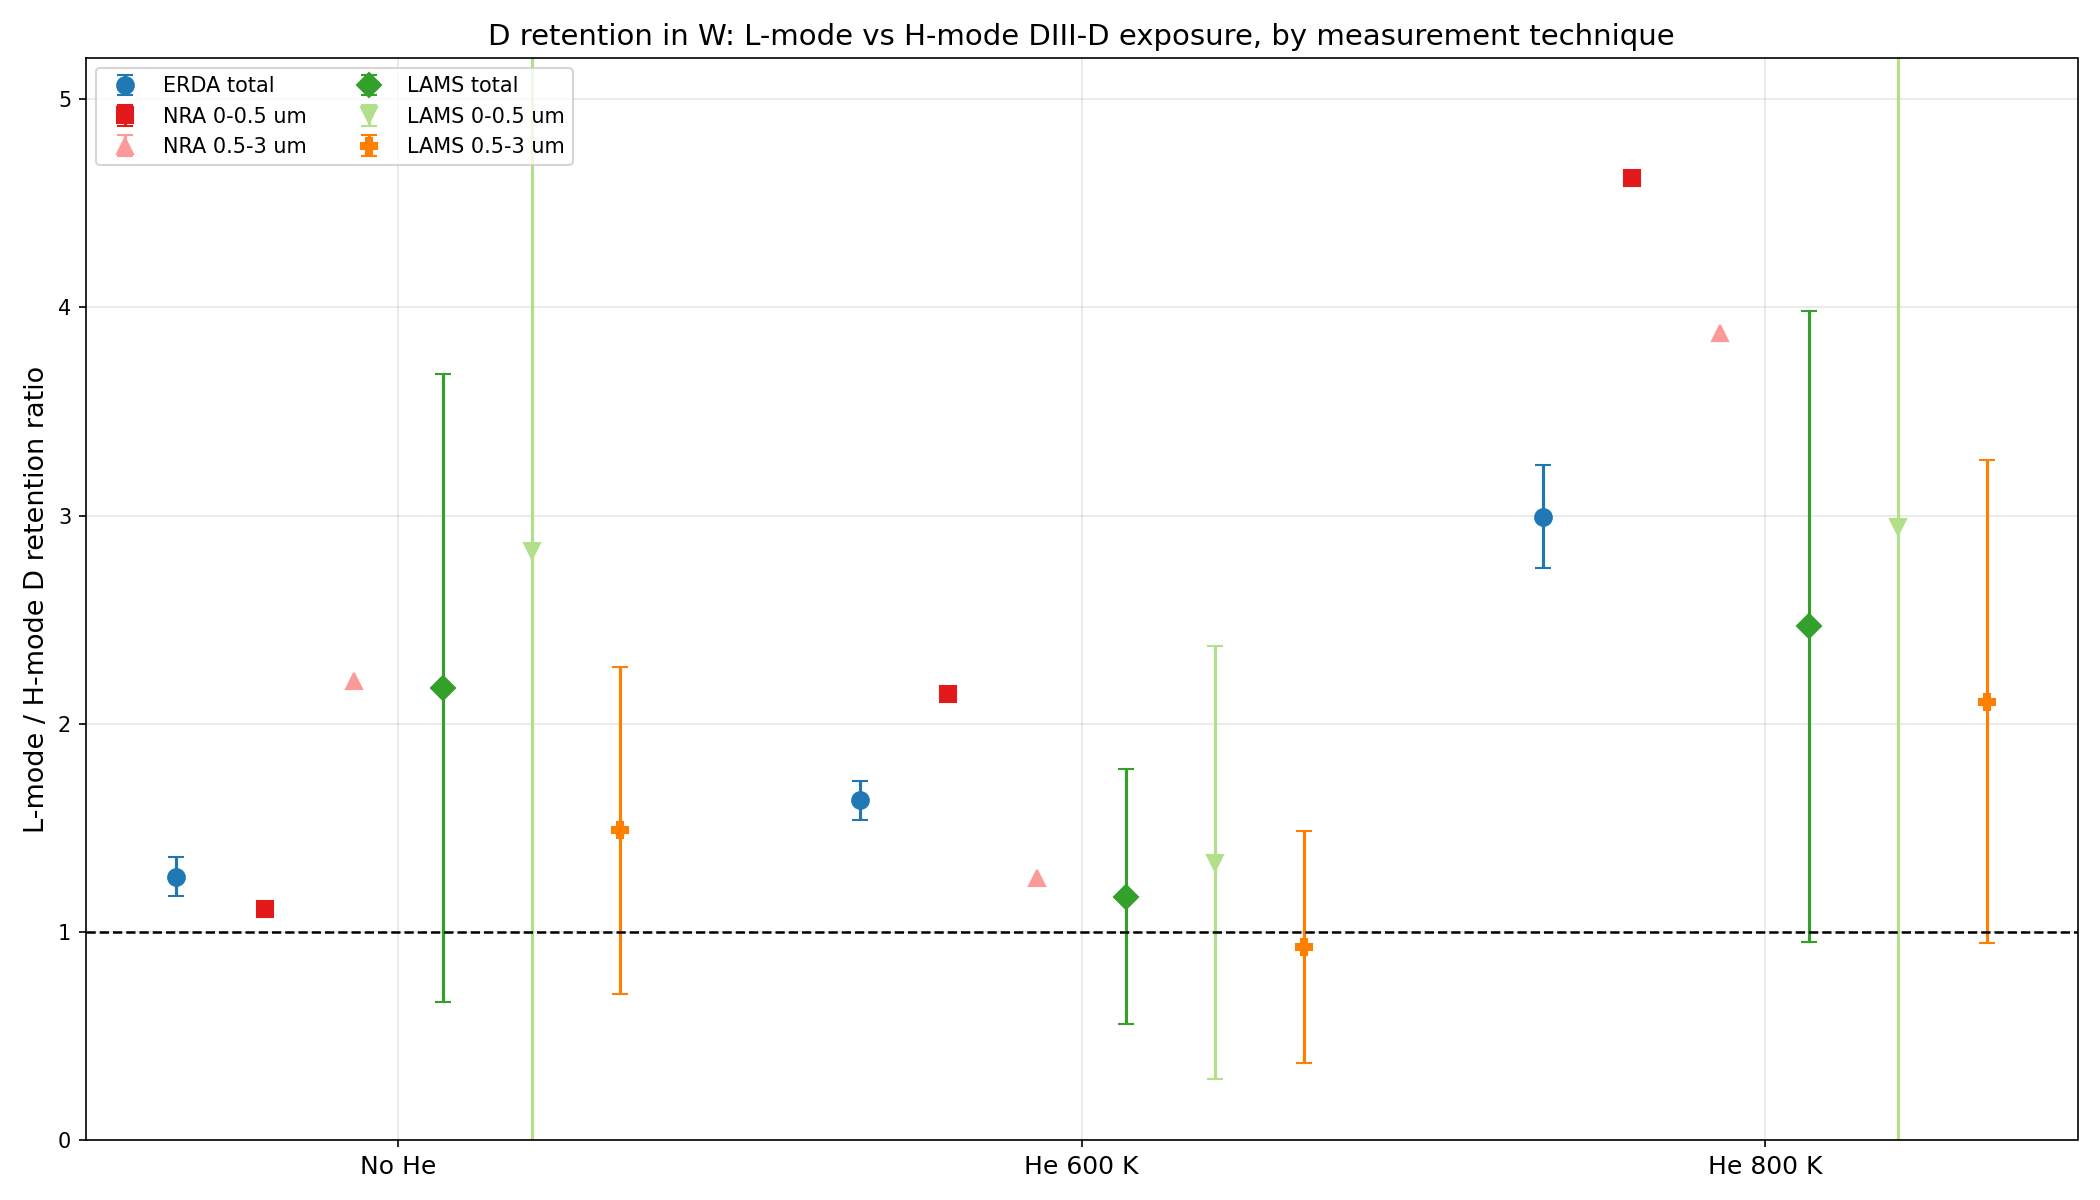


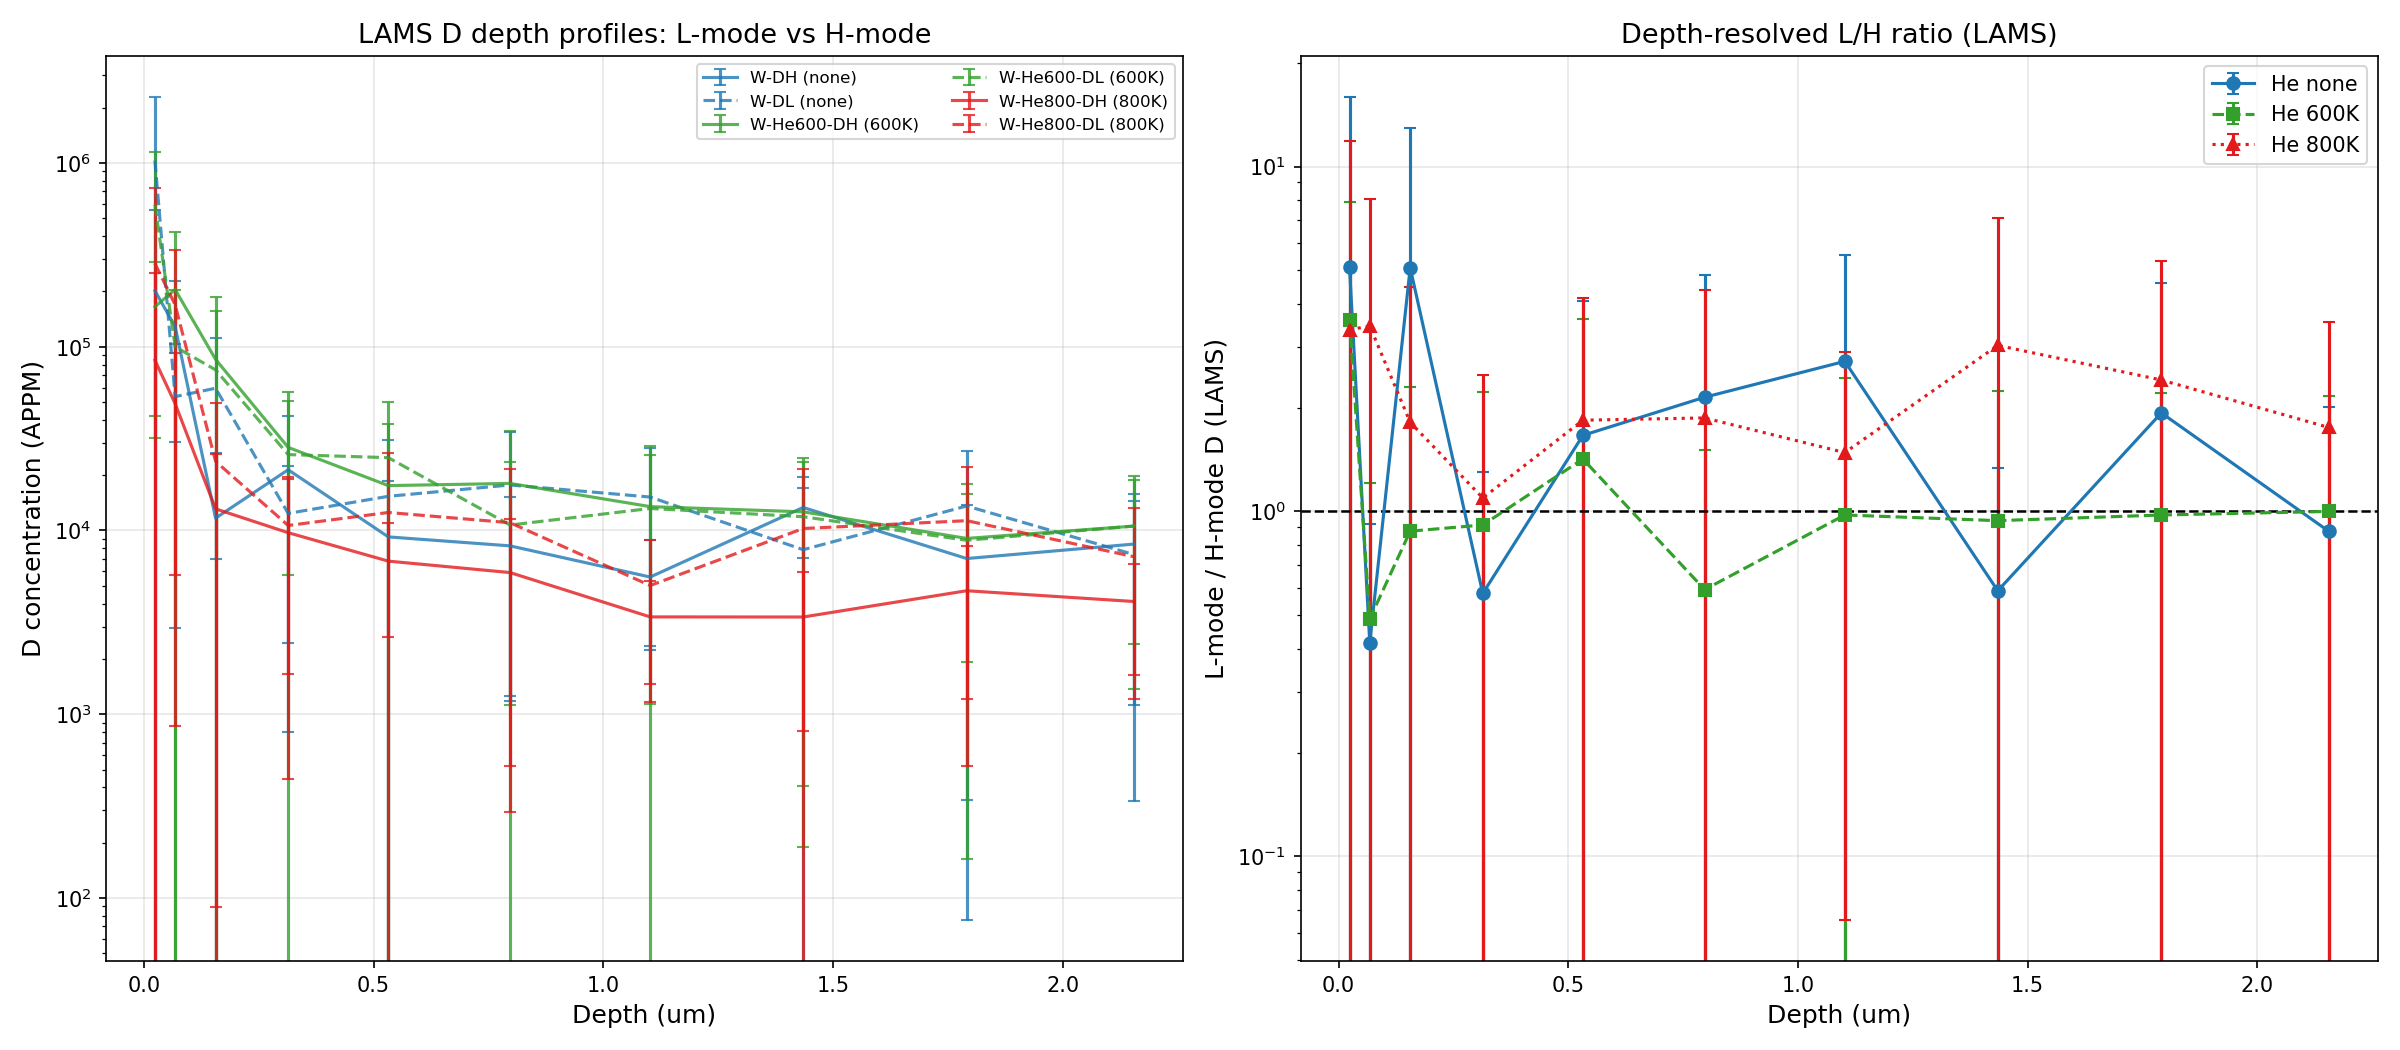

## Data files

- `lh_mode_ratios.csv` — L/H-mode D retention ratios by technique (ERDA total, NRA surface/subsurface, LAMS total/bands) with propagated uncertainties
- `lh_mode_lams_depth.csv` — per-depth-point LAMS L/H ratios with propagated uncertainties
- `lh_mode_ratios.png` — comparison of L/H ratios by technique
- `lh_mode_depth_profiles.png` — LAMS depth profiles (L vs H) and depth-resolved L/H ratios

In [4]:
%%ask --review
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used.

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


I'll check what other measurement types exist in the lakehouse for these samples (TDS, microscopy, etc.) before characterizing the gaps, then write the limitations analysis.

Running the enumeration script to see the full inventory of measurement types.

The class name differs from my assumption. Let me check the helper module's actual API surface.

The helper uses module-level functions rather than a client class. Let me find the function names.

Let me read the helper module directly to understand its API.

...

Both files now land inside the working directory. That string-concatenation path bug was a classic — recording it in Learnings before continuing.

Now saving the gap inventory as a data file so the report's claims are checkable.

All analysis is complete. Marking the final todo and writing the report.

Before writing the report, let me verify what the isotope figure actually plots so the caption is accurate.

# What this analysis cannot claim — and what measurements would be needed

**The short answer:** the analysis can describe *what happened to these nine specific coupons*, but it cannot support claims about *mechanism*, *causation*, *total inventory*, or *extrapolation beyond the probed conditions*. The five hardest walls are: one coupon per experimental cell (no statistics), a confounded L-vs-H comparison (fluence, energy, Te, ne and heat flux all change together), no sample temperature measurement during DIII-D exposure, no trap-spectroscopy (TDS), and no post-exposure microscopy. And one new finding from this session sharpens the limit further: when the co-retained protium is included, part of the apparent "He effect on D retention" becomes an *isotope-exchange* effect, not a retention effect.

## 1. What the analysis is NOT sufficient to claim

**1.1 "He causes X" — no causal separation at n = 1.** The 3×2 factorial (He: none/600 K/800 K × regime: L/H) contains exactly one coupon per cell, confirmed by `design()`: every group has `n_samples: 1`. Every ratio quoted in the earlier reports (0.23–4.62) is a comparison of two individual coupons. With no replicates there is no within-cell variance estimate, so no confidence interval, no significance test, and no way to distinguish a treatment effect from coupon-to-coupon variation in the as-received tungsten. The ERDA σ (±4–7%) is *instrument* repeatability, not sample variability.

**1.2 "L-mode retains more than H-mode" — the comparison is confounded five ways.** The two regimes differ simultaneously in D⁺ impact energy (175 vs 150 eV), Te (40.8 vs 27.9 eV), ne (7.35 vs 5.76×10¹⁸ m⁻³), particle flux (7.5 vs 4.5×10²¹ m⁻²s⁻¹), fluence (7.8 vs 6.7×10²² m⁻²), and heat flux (0.47 vs 0.72 MW m⁻²). A single-variable attribution ("it's the mode") is not identifiable from this data. The per-fluence normalization only removes one of the six differences.

**1.3 "The He layer blocks/supplies traps" — any mechanism claim is unverified.** The permeation-barrier language comes from the proposal's literature hypothesis ([8], via its Figure 1), not from a measurement of *where He sits relative to D at trap resolution* or *what the traps are*. Testing it needs trap spectroscopy and microstructure (below).

**1.4 "D retention increased/decreased by X%" — only within the top ~3 µm.** NRA resolves 0–0.5 and 0.5–3 µm; LAMS reaches 2.155 µm; ERDA integrates only ~0.2 µm. Anything deeper — bulk diffusion, long-range trapping — is invisible. The reported "total" is a near-surface total. Likewise the fluence-normalized retention is tiny (D retained ≈ 7–13 ×10⁻⁵ of incident D⁺; D+H ≈ 12–22 ×10⁻⁵), so the overall recycling fraction ≈ 99.99%, but the *unmeasured* deeper inventory could change the total materially.

**1.5 "Thermal history played no role" — unverifiable; temperature was not measured.** The exposure-2 summary tabulates Te, ne, flux, heat flux per shot, but the "Sample temperature" column of the availability sheet was never populated for DIII-D, and the IRTV temperatures the proposal planned (to "estimate the maximum sample temperature during the discharge (high temperatures may induce excessive desorption of implanted gas)") were not delivered. Since D trapping/detrapping in W is strongly temperature-dependent, any L/H difference could be partly a *sample-temperature* difference — the data cannot arbitrate.

**1.6 "Surface He was eroded in L-mode" — inferred from LAMS only.** The analyst's note ("L-mode exposures on He-800 sample removed most surface He…") rests on the technique whose median σ/value ≈ 0.88, and no post-exposure SEM exists to confirm it: the delivery's 327 pre-characterization artifacts are SEM images from *before* PISCES/DIII-D, and the post-exposure artifacts are only the two spreadsheets (`erda_nra_data.xlsx`, `LAMS data.xlsx`). No post-exposure morphology data exists for any of the 9 coupons.

**1.7 "The He effect on hydrogen retention" — isotope exchange is unquantified except in the ERDA layer.** ERDA reports H alongside D (NRA and LAMS do not), and the H behaves differently: **H/D ranges 0.63–1.96 across coupons** , and when the He effect is recomputed on D+H combined, the picture changes materially:

| Comparison (ERDA) | D ratio | (D+H) ratio |
|---|---|---|
| He 600 K, H-mode | 1.27 | 0.91 |
| He 800 K, H-mode | 0.58 | 0.71 |
| He 600 K, L-mode | 1.63 | 1.23 |
| He 800 K, L-mode | 1.36 | 0.96 |

The large L-mode 800 K "increase" in D (+36%) essentially vanishes on D+H (0.96), and the 600 K H-mode increase (+27%) reverses sign (0.91). Since H and D compete for the same trap population, part of what the D-only analysis called "retention change" is redistribution between isotopes. The depth-resolved techniques cannot check this — they measure D only. This is a *within-data* limitation I can quantify (above) but not resolve.

**1.8 Significance of NRA-based claims — untestable.** NRA carries no uncertainty column, so none of the NRA ratios have error bars. The strongest-significance statements in the whole dataset remain the ERDA ones (L/H z = 2.9–8.0), and they cover only the top ~0.2 µm.

**1.9 "Retention, not redeposition."** NRA's surface C varies ~4× across coupons (1.15–4.47×10¹⁶ cm⁻²), rising after DIII-D exposure (e.g. W-He800-DH has the most C *and* an anomalous H/D). Impurity carbon binds D strongly; the data cannot separate trapped-from-plasma D from D held in co-deposited C.

## 2. What measurement would be needed to go further

| To claim | Measurement needed | Why it answers it |
|---|---|---|
| Trap energies / what holds the D / how He changes trapping | **TDS** on the coupons (ramped desorption, rate-analysis for E_t). The UCSD TDS hardware already exists in this program (used for bake-out) | Desorption peaks map directly onto trap depths; He-shifted peaks are the direct test of the barrier hypothesis (the proposal's Figure 1 is exactly this literature technique) |
| Statistical significance of any He or regime effect | **Replicate coupons** : n ≥ 3 per cell, randomized positions in the DiMES cap | Converts ratios into differences-with-error-bars; separates coupon variance from treatment effect |
| "It's the plasma regime, not the temperature" | **Sample temperature during exposure** — IRTV reconstruction (planned but undelivered) or embedded thermocouple / pyrometry on the DiMES cap | Gives the missing state variable; lets retention be compared at matched T, or modeled with T-dependent trapping |
| Total inventory beyond 3 µm | **Higher-energy NRA** (multi-energy ³He extends depth), **SIMS** (deep profiles, though H/D/D₂⁺ mass discrimination is hard), or **neutron depth profiling** | Quantifies the deep/bulk term the current delivery cannot see |
| Microstructure mechanism (bubbles vs fuzz vs blisters) | **Post-exposure SEM + cross-sectional TEM** on the exposed coupons | Images the He bubble layer's depth and morphology; connects it to where NRA/LAMS see D suppressed |
| Isotope-exchange vs true retention change | **H and D measured by the depth-resolved techniques** (e.g. ERDA profiling, or isotope-resolved SIMS), or a controlled D-then-H sequential exposure series | Separates "D replaced by H in the same traps" from "traps emptied" — the confound quantified in §1.7 |
| Recycling vs retention (the ~99.99% that left) | **Absolutely calibrated Dα/D₂ spectroscopy** (the FASTCAM channels exist but are in a.u. and only cover the 3 H-mode coupons) + recycling modeling | Closes the particle balance the retention data alone leaves open |
| Erosion–retention coupling | **Surface profilometry / mass loss / RBS W-loss** on the coupons (the DiMES/QCM erosion aim of the proposal) | Retention per unit *remaining* material, and the erosion release path |

**Priority order** , judged by what most limits the current claims: (1) TDS — it is the single measurement that most directly tests the mechanism all three techniques are circling; (2) replicate coupons — without them no claim clears the n = 1 bar; (3) exposure thermometry — the missing state variable; (4) post-exposure SEM/TEM — cheap, and it would confirm or kill the L-mode He-erosion story currently resting on LAMS alone.

## 3. New quantitative result from this session


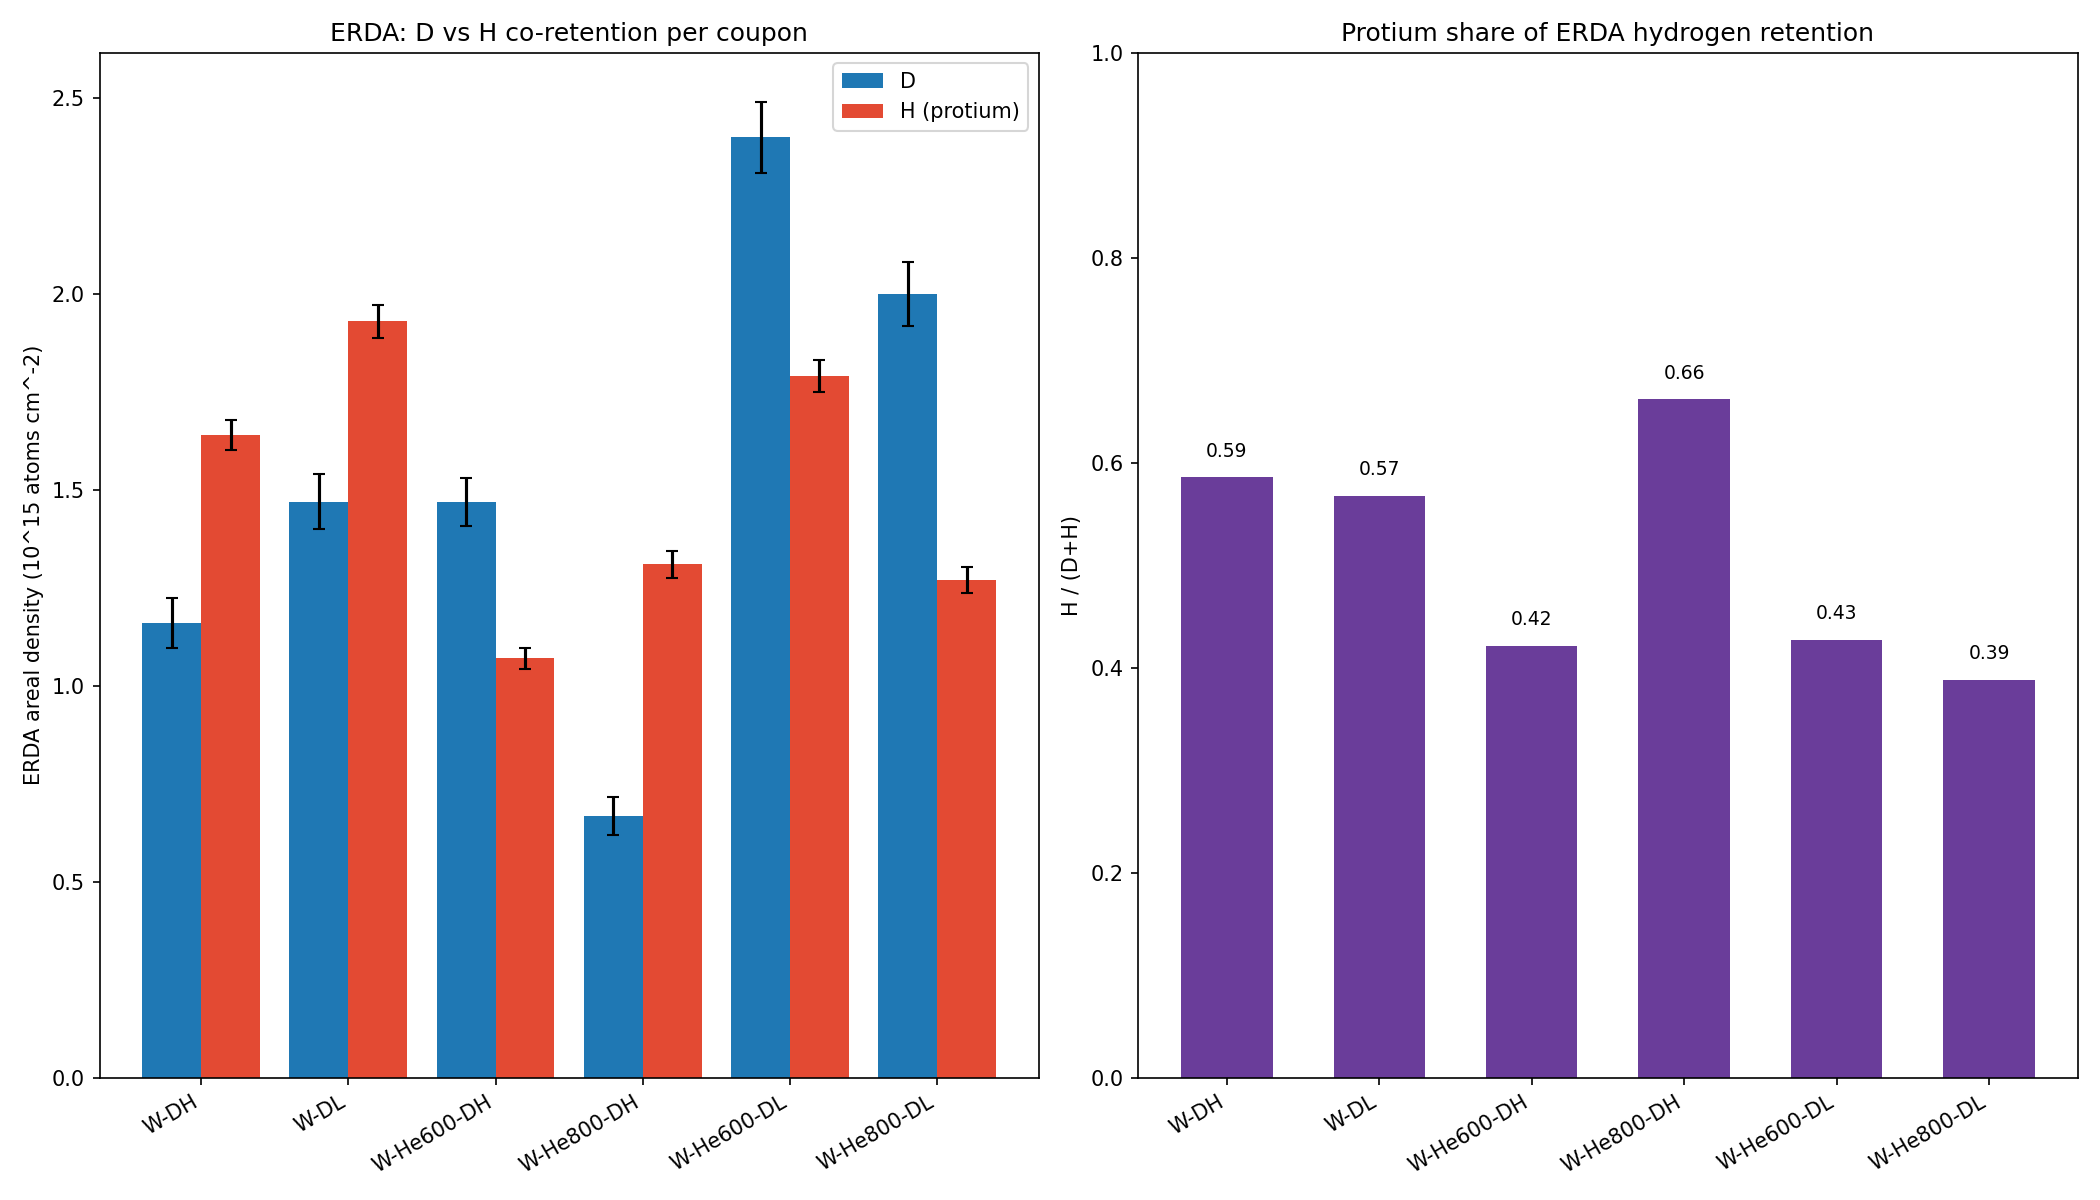

ERDA's H channel, not used in the earlier reports, shows H/D = 0.63–1.96 (H is 39–66% of retained hydrogen: W-He800-DH has the highest protium share at 0.66, W-He800-DL the lowest at 0.39), and retained D is only 0.007–0.013% of incident D⁺ fluence (D+H: 0.012–0.022%). The He-effect ratios computed on D+H (0.71–1.23) are systematically closer to 1 than the D-only ratios (0.58–1.63) — see §1.7. This does not overturn the D-only findings, but it bounds their interpretation: a fraction of each "D retention change" is isotope exchange, quantifiable only in the ERDA depth layer.

## Data files

- `measurement_gaps.csv` — the gap inventory: missing capability, its status in the delivery, and the claim it limits
- `isotope_competition_erda.csv` — per-coupon ERDA D and H areal densities with σ, H/D, D and D+H as fractions of incident fluence
- `isotope_competition_erda.png` — the isotope co-retention figure above

In [1]:
%%ask --review
What would this analysis NOT be sufficient to claim, and what measurement would 
be needed to go further?